# Data Preprocessing and Exploration

## Cell 1: Data Loading and Initial Overview

In this step, the raw data for the **HRH1 target** is imported into a pandas dataframe.

### Key Dataset Characteristics:
* **Molecules:** 1,650
* **Columns (Features):** 48

### Key Columns Identified:
* **Structural Data:** `Smiles`
* **Target Metrics:** `Standard Value`, `pChEMBL Value`

The sheer number of columns indicates that a significant amount of experimental metadata is present. The next steps will require filtering out unnecessary identifiers and focusing on the core structural representations and activity measurements for predictive modeling.

In [4]:
import pandas as pd
from pipelines import train_and_get_predictions, compare_model_predictions, plot_model_performance
df = pd.read_csv('data/HRH1.csv', sep=';')

n_rows = df.shape[0]
n_cols = df.shape[1]
print(f"Number of rows: {n_rows} and number of columns: {n_cols}")
print(df.columns.tolist())
display(df.head(3))

Number of rows: 1650 and number of columns: 48
['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL2208420,NaN,NaN,405.33,1.0,5.18,12,N#Cc1cccc(OCCCN2CCC(Oc3ccc(Cl)c(Cl)c3)CC2)c1,Ki,'=',...,CHEMBL2202969,1,Scientific Literature,Bioorg Med Chem Lett,2012.0,CHEMBL3307512,NaN,NaN,NaN,7.9
1,CHEMBL1000,CETIRIZINE,4.0,388.90,0.0,3.15,3,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,Ki,'=',...,CHEMBL1221171,1,Scientific Literature,Nat Chem Biol,2005.0,CHEMBL3307648,NaN,NaN,NaN,7.3
2,CHEMBL272702,NaN,NaN,542.71,1.0,4.67,16,CC(=O)N1CCOc2cc3c(cc21)CCN(CCCSc1nnc(-c2cccc4n...,Ki,'=',...,CHEMBL1142271,1,Scientific Literature,Bioorg Med Chem Lett,2008.0,NaN,NaN,NaN,NaN,6.0


### Data Cleaning and Feature Selection

In this step, the dataset is reduced from 48 columns down to the essential ones needed for modeling and filtering.

#### Retained Features:
* **Identifiers & Structure:** `Smiles`
* **Activity Metrics:** `Standard Value`
* **Target Variable:** `pChEMBL Value`

All other metadata columns regarding assays, documents, and target details are dropped to simplify the dataframe and optimize it for predictive modeling.

In [6]:
columns_to_keep = [
    'Smiles', 
    'Standard Value', 
    'pChEMBL Value', 
]
df = df[columns_to_keep].copy()

print(f"Origin number of columns: {df.shape[1]}")
print(f"New number of columns: {df.shape[1]}")
display(df.head())

Origin number of columns: 3
New number of columns: 3


,Smiles,Standard Value,pChEMBL Value
0,N#Cc1cccc(OCCCN2CCC(Oc3ccc(Cl)c(Cl)c3)CC2)c1,12.59,7.9
1,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,50.12,7.3
2,CC(=O)N1CCOc2cc3c(cc21)CCN(CCCSc1nnc(-c2cccc4n...,1000.00,6.0
3,Cc1ncoc1-c1nnc(SCCCN2CCc3cc4c(cc3CC2)N(C)C(=O)...,1995.26,5.7
4,O=C(O)C1=CCCN(C2CC[C@]3(Cc4ccccc4Cc4ccccc43)C2)C1,19.95,7.7


### Outlier Removal and Deduplication

This step cleans the dataset by removing extreme outliers and standardizing chemical structures to ensure data quality.

#### Key Actions:
* **Outlier Filtering:** Measurements with a `Standard Value` above 1,000,000 are dropped, as these represent practically inactive compounds that add noise to the model.
* **Structure Standardization:** The script utilizes **RDKit** to parse chemical structures and generate **canonical SMILES strings**. This ensures that identical molecules represented in different ways are unified under a single structural standard.
* **Deduplication:** Duplicate entries are handled by grouping identical canonical SMILES strings and calculating the **median value** for their activity metrics.

The resulting clean dataset contains only unique molecules and is ready for feature generation.

In [3]:
from rdkit import Chem
import numpy as np

print(f"\nOriginal dataset size: {len(df)} molecules")

df = df[df['Standard Value'] < 1_000_000]
print(f"After filtering and removing outliers: {len(df)} molecules")

print("\nGenerating canonical SMILES for deduplication...")
df["mol"] = df["Smiles"].apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)
df = df.dropna(subset=["mol"])
df["canonical_smiles"] = df["mol"].apply(lambda x: Chem.MolToSmiles(x, isomericSmiles=True))

print(f"Valid molecules after canonicalization: {len(df)}")

df = df.groupby('canonical_smiles').agg({
    'Standard Value': 'median',
    'pChEMBL Value': 'median' 
}).reset_index()

print(f"After deduplication (by canonical SMILES): {len(df)} unique molecules")

df = df.rename(columns={'canonical_smiles': 'Smiles'})


print(f"Final dataset ready for modeling: {len(df)} unique molecules\n")
display(df.head(5))


Original dataset size: 1650 molecules
After filtering and removing outliers: 1612 molecules

Generating canonical SMILES for deduplication...
Valid molecules after canonicalization: 1612
After deduplication (by canonical SMILES): 1369 unique molecules
Final dataset ready for modeling: 1369 unique molecules



,Smiles,Standard Value,pChEMBL Value
0,Br.CN1CCc2cc(Br)c(O)cc2C(c2ccccc2)C1,760.940,6.120
1,Br.c1ccc2c(c1)CCN(CCCc1nc3ccccc3s1)C2,817.415,6.085
2,C(#Cc1c2c(nc3ccccc13)CCCCC2)CCN1CCCCC1,15733.000,4.800
3,C(=C\c1ccccc1)/CN1CCN(C(c2ccccc2)c2ccccc2)CC1,8.622,8.060
4,C/C(=N\NC(=O)[C@@H]1C(=O)NC[C@H]1c1ccccc1)c1cc...,1979.700,5.700


### Logarithmic Transformation

In this step, a logarithmic transformation is applied directly to the `Standard Value` using `pandas`.

#### Key Highlights:
* **Scale Compression:** This approach compresses the wide range of linear nanomolar concentrations into a tighter, more manageable logarithmic scale.
* **Target Variable:** The resulting values are stored in a new column named `Standard_log_value`, which will serve as the target variable for the predictive models.

In [4]:
import numpy as np

print("Data Transformation: Applying log10 to Standard Value")

df['Standard_log_value'] = df['Standard Value'].apply(np.log10)

df = df[['Smiles', 'Standard_log_value']]

print(f"Transformation complete. Dataset size: {len(df)} molecules")
display(df.head(5))

Data Transformation: Applying log10 to Standard Value
Transformation complete. Dataset size: 1369 molecules


,Smiles,Standard_log_value
0,Br.CN1CCc2cc(Br)c(O)cc2C(c2ccccc2)C1,2.881350
1,Br.c1ccc2c(c1)CCN(CCCc1nc3ccccc3s1)C2,2.912443
2,C(#Cc1c2c(nc3ccccc13)CCCCC2)CCN1CCCCC1,4.196812
3,C(=C\c1ccccc1)/CN1CCN(C(c2ccccc2)c2ccccc2)CC1,0.935608
4,C/C(=N\NC(=O)[C@@H]1C(=O)NC[C@H]1c1ccccc1)c1cc...,3.296599


### Molecule Processing and Salt Stripping

In this step, the SMILES strings are processed to ensure the chemical structures are clean and properly formatted for feature engineering.

#### Key Steps:
* **RDKit Object Conversion:** SMILES strings are converted into RDKit molecule objects, which is a strict prerequisite for generating molecular descriptors. Invalid structures that cannot be parsed are automatically dropped.
* **Salt Stripping:** A salt stripper is applied to remove counterions (such as chlorides or sodium) from the chemical structures. This ensures that the machine learning models learn exclusively from the active pharmaceutical ingredient and are not confused by the extra molecular weight or atoms of inactive salts.
* **Structure Synchronization:** The SMILES strings are updated to accurately reflect the newly stripped, neutralized structures.

In [5]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover

print("Molecule Processing: Generating RDKit objects and stripping salts")

remover = SaltRemover()

df['Mol'] = df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)
df = df.dropna(subset=['Mol'])

df['Mol'] = df['Mol'].apply(lambda x: remover.StripMol(x, dontRemoveEverything=True))
df = df.dropna(subset=['Mol'])

df['Smiles'] = df['Mol'].apply(Chem.MolToSmiles)

print(f"Valid and stripped molecules ready: {df.shape[0]}")

Molecule Processing: Generating RDKit objects and stripping salts
Valid and stripped molecules ready: 1369


### Descriptor and Fingerprint Generation

In this step, meaningful numerical features are extracted from the cleaned chemical structures to serve as inputs for the machine learning models.

#### 1. Physicochemical Descriptors
The script calculates key properties, including:
* **Molecular Weight**
* **LogP** (Octanol-water partition coefficient)
* **Hydrogen Bond Donors and Acceptors** (Number of)

#### 2. Structural Fingerprints
To provide a mathematical representation of the chemical space, the following binary vectors are generated:
* **MACCS Keys:** Structural keys that represent the presence or absence of specific substructures.
* **Morgan Fingerprints:** Calculated with a **radius of 2** and a bit length of **2048 bits** to capture detailed local atom environments.

These combined features establish the essential data representation required for training predictive models.

In [6]:
import numpy as np
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator

print("Feature Generation: Calculating Descriptors and Fingerprints")

df['MW'] = df['Mol'].apply(Descriptors.MolWt)
df['LogP'] = df['Mol'].apply(Descriptors.MolLogP)
df['HBD'] = df['Mol'].apply(Descriptors.NumHDonors)
df['HBA'] = df['Mol'].apply(Descriptors.NumHAcceptors)

df['MACCS'] = df['Mol'].apply(lambda x: np.array(MACCSkeys.GenMACCSKeys(x)))

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
df['Morgan_FP'] = df['Mol'].apply(lambda x: np.array(morgan_gen.GetFingerprint(x)))

columns_to_show = ['Smiles', 'MW', 'LogP', 'HBD', 'HBA']
print("\nPhysicochemical Descriptors Preview:")
display(df[columns_to_show].head(2))

print("\nFingerprint Vectors Shape Preview:")
print(f"MACCS array length per molecule: {len(df['MACCS'].iloc[0])}")
print(f"Morgan array length per molecule: {len(df['Morgan_FP'].iloc[0])}")

Feature Generation: Calculating Descriptors and Fingerprints

Physicochemical Descriptors Preview:


,Smiles,MW,LogP,HBD,HBA
0,CN1CCc2cc(Br)c(O)cc2C(c2ccccc2)C1,332.241,3.7745,1,2
1,c1ccc2c(c1)CCN(CCCc1nc3ccccc3s1)C2,308.450,4.2872,0,3



Fingerprint Vectors Shape Preview:
MACCS array length per molecule: 167
Morgan array length per molecule: 2048


### Loading Precomputed Embeddings

This step loads two different learned molecular representations from disk: MolDeBERTa and Molformer. Both are transformer-based embeddings, which means they convert each molecule into a dense numerical vector that captures chemical structure, substructure patterns, and contextual relationships between atoms.

- **MolDeBERTa** is a language-model-style encoder adapted for molecules. It is designed to learn rich semantic features from molecular strings and usually produces embeddings that reflect higher-level chemical patterns.
- **Molformer** is another transformer-based molecular representation model that focuses on learning structure-aware embeddings for small molecules. It is often used to capture relationships that are difficult to describe with hand-crafted descriptors.

These embeddings are converted into pandas DataFrames so they can be compared, analyzed, and used as input features for machine learning models.

In [ ]:
moldeberta = np.load('embeddings_output/moldeberta_embeddings.npy')
molformer = np.load('embeddings_output/molformer_embeddings.npy')
df_molformer = pd.DataFrame(molformer)
df_moldeberta = pd.DataFrame(moldeberta)

### Activity Classification and Physicochemical Space Analysis

In this step, the molecules are categorized into distinct activity classes based on their transformed target values to facilitate exploratory data analysis (EDA).

#### Key Analysis Components:
* **Activity Categorization:** Molecules are grouped into classes to enable a visual comparison of physicochemical properties between highly active compounds and less active ones.
* **Property Distribution via Boxplots:** Boxplots are used to analyze the distributions of **Molecular Weight** and **LogP** across the defined activity classes.
* **Property-Activity Correlation:** This visual inspection helps determine if biological activity correlates with specific property ranges, such as a preference for larger or highly lipophilic molecules within the target binding site.

Activity Classification and Physicochemical Space Analysis

Class Distribution:
Activity_Class
High Activity (< 100 nM)         612
Low Activity (> 1000 nM)         430
Medium Activity (100-1000 nM)    327
Name: count, dtype: int64


/tmp/ipykernel_629190/2118955535.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Activity_Class', y='MW', ax=axes[0], palette="Set2", order=class_order)
/tmp/ipykernel_629190/2118955535.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Activity_Class', y='LogP', ax=axes[1], palette="Set2", order=class_order)


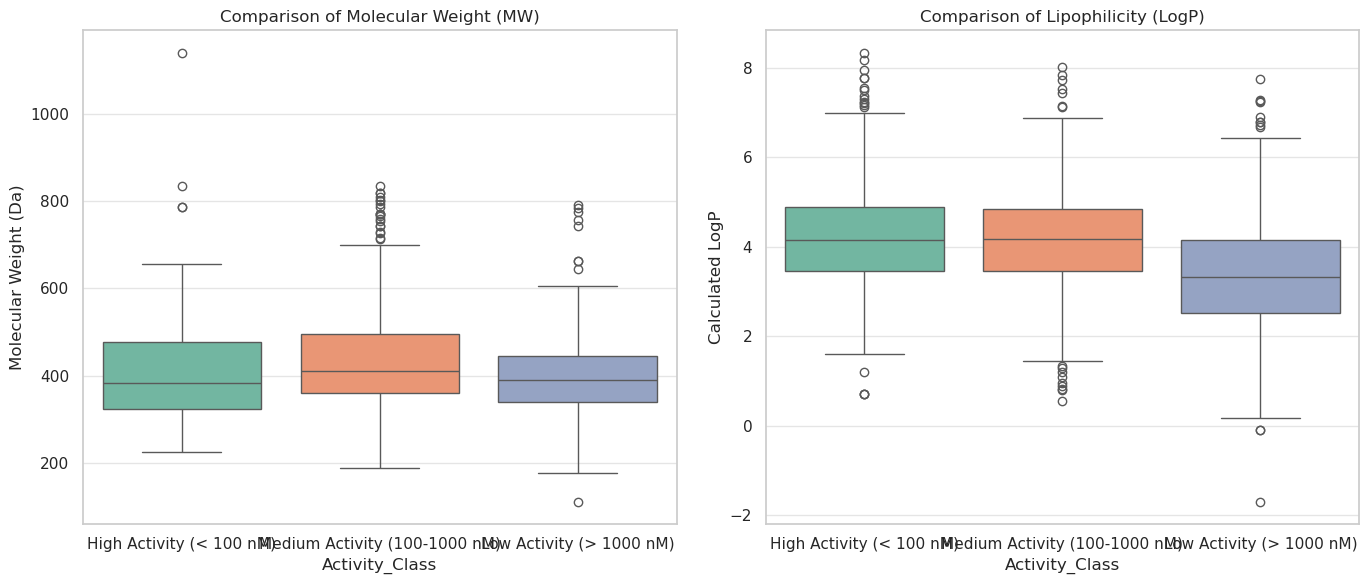

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Activity Classification and Physicochemical Space Analysis")

def classify_activity(log_value):
    if log_value <= 2.0:
        return 'High Activity (< 100 nM)'
    elif log_value <= 3.0:
        return 'Medium Activity (100-1000 nM)'
    else:
        return 'Low Activity (> 1000 nM)'

df['Activity_Class'] = df['Standard_log_value'].apply(classify_activity)

print("\nClass Distribution:")
print(df['Activity_Class'].value_counts())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_order = ['High Activity (< 100 nM)', 'Medium Activity (100-1000 nM)', 'Low Activity (> 1000 nM)']

sns.boxplot(data=df, x='Activity_Class', y='MW', ax=axes[0], palette="Set2", order=class_order)
axes[0].set_title('Comparison of Molecular Weight (MW)')
axes[0].set_ylabel('Molecular Weight (Da)')

sns.boxplot(data=df, x='Activity_Class', y='LogP', ax=axes[1], palette="Set2", order=class_order)
axes[1].set_title('Comparison of Lipophilicity (LogP)')
axes[1].set_ylabel('Calculated LogP')

plt.tight_layout()
plt.show()

### Results Interpretation

The dataset has been successfully categorized into active sub-classes, revealing important structural trends for model training.

#### 1. Class Distribution
The dataset is split into:
* **Highly Active:** 612 compounds
* **Moderately Active:** 327 compounds
* **Low Activity:** 429 compounds

This distribution provides a healthy balance for machine learning models compared to raw, highly imbalanced data.

#### 2. Physicochemical Space Trends
* **Molecular Weight (MW):** Shows only weak discriminatory power. There is a slight median shift towards heavier structures (around 350 Da) for highly active compounds.
* **Lipophilicity (LogP):** Demonstrates a distinct and crucial biological trend. Higher binding activity strongly correlates with increased LogP values. The highly active class centers around a LogP of 3.5 to 4.0, indicating that the histamine H1 receptor binding pocket is notably hydrophobic and prefers lipophilic molecules.

### Murcko Scaffold Analysis

In this step, a scaffold analysis is performed using Bemis-Murcko frameworks to evaluate structural diversity and identify core chemotypes.

#### Key Methodology:
* **Side-Chain Stripping:** This technique strips away all terminal side chains from the molecules, leaving only the core ring systems and their connecting linkers.
* **Backbone Identification:** By grouping the dataset by these core scaffolds, the most frequently occurring chemical backbones can be identified.
* **Visualization:** The top four most common scaffolds are visualized directly.

This structural analysis is critical for understanding the chemical diversity of the dataset and identifying the privileged structural motifs that are predominantly explored against the target receptor.

Structural Analysis: Extracting Top Bemis-Murcko Scaffolds
Total unique scaffolds identified: 710


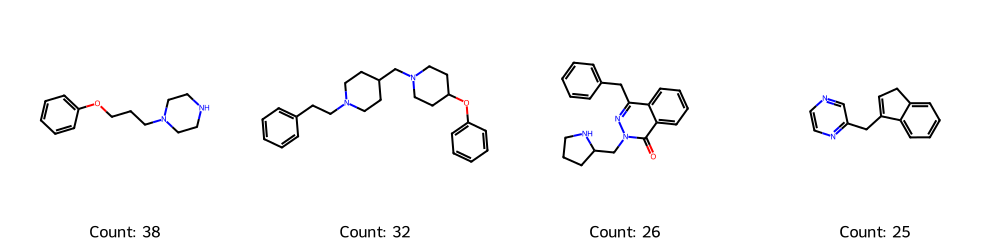

In [9]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit import Chem

print("Structural Analysis: Extracting Top Bemis-Murcko Scaffolds")

df['Scaffold_SMILES'] = df['Mol'].apply(lambda x: MurckoScaffold.MurckoScaffoldSmiles(mol=x))

scaffold_counts = df['Scaffold_SMILES'].value_counts()
print(f"Total unique scaffolds identified: {len(scaffold_counts)}")

top_scaffolds_smiles = [s for s in scaffold_counts.index if s != ''][:4]
top_scaffolds_mols = [Chem.MolFromSmiles(s) for s in top_scaffolds_smiles]
top_scaffolds_labels = [f"Count: {scaffold_counts[s]}" for s in top_scaffolds_smiles]

if top_scaffolds_mols:
    img = Draw.MolsToGridImage(
        top_scaffolds_mols, 
        molsPerRow=4, 
        subImgSize=(250, 250), 
        legends=top_scaffolds_labels,
    useSVG=True
    )
    display(img)
else:
    print("No valid cyclic scaffolds found in the dataset.")

### Advanced Dimensionality Reduction

This comprehensive step maps the high-dimensional chemical space represented by the 2048-bit Morgan Fingerprints into 2D spaces using PCA, t-SNE, and UMAP.

#### Dimensionality Reduction Techniques:
* **PCA (Principal Component Analysis):** Provides a linear baseline, demonstrating how much variance is captured in the leading components.
* **t-SNE & UMAP:** State-of-the-art non-linear manifold learning techniques utilized to visualize intricate structural similarities.

#### Analysis Goals:
* **Structural Proximity:** Molecules positioned closer together in these low-dimensional plots share similar bit-patterns (structural features).
* **Activity Overlay:** Overlaying the activity classes onto these embeddings helps visualize whether structural similarity corresponds to biological activity—a foundational concept in rational drug design.

/home/ubuntu/miniconda3/envs/CDD/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Advanced Dimensionality Reduction: PCA, t-SNE, and UMAP
Feature Space Shape: (1369, 2048) | Variance Range: [0, 1]
PCA Variance (First 2 PC): 0.0269


/home/ubuntu/miniconda3/envs/CDD/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


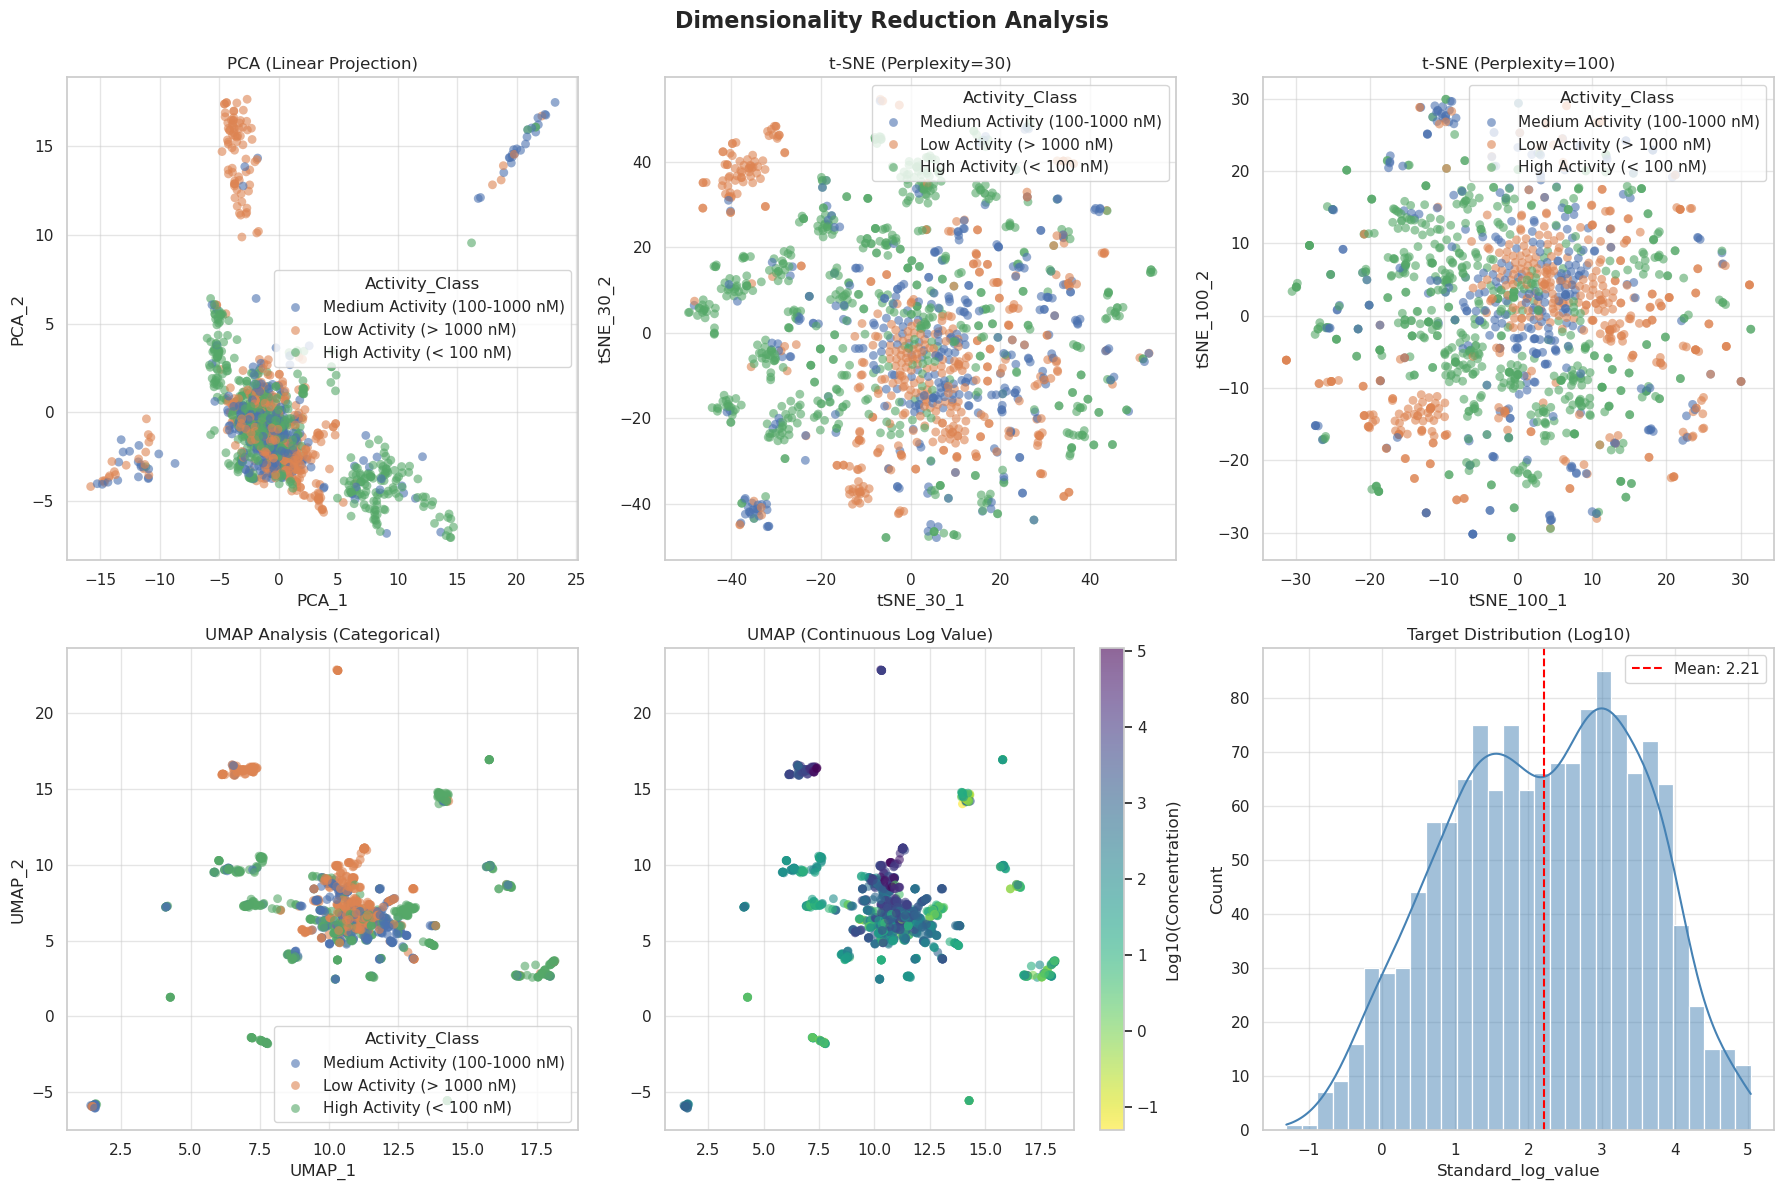

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

print("Advanced Dimensionality Reduction: PCA, t-SNE, and UMAP")

X = np.array(df['Morgan_FP'].tolist())
print(f"Feature Space Shape: {X.shape} | Variance Range: [{X.min()}, {X.max()}]")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'], df['PCA_2'] = X_pca[:, 0], X_pca[:, 1]
print(f"PCA Variance (First 2 PC): {sum(pca.explained_variance_ratio_):.4f}")

tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_30 = tsne_30.fit_transform(X_scaled)
df['tSNE_30_1'], df['tSNE_30_2'] = X_tsne_30[:, 0], X_tsne_30[:, 1]

tsne_100 = TSNE(n_components=2, perplexity=100, random_state=42, max_iter=1000)
X_tsne_100 = tsne_100.fit_transform(X_scaled)
df['tSNE_100_1'], df['tSNE_100_2'] = X_tsne_100[:, 0], X_tsne_100[:, 1]

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_epochs=1000)
X_umap = reducer.fit_transform(X_scaled)
df['UMAP_1'], df['UMAP_2'] = X_umap[:, 0], X_umap[:, 1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Dimensionality Reduction Analysis', fontsize=16, fontweight='bold', y=0.99)

ax = axes[0, 0]
sns.scatterplot(data=df, x='PCA_1', y='PCA_2', hue='Activity_Class', alpha=0.6, s=40, ax=ax, edgecolor='none')
ax.set_title('PCA (Linear Projection)')

ax = axes[0, 1]
sns.scatterplot(data=df, x='tSNE_30_1', y='tSNE_30_2', hue='Activity_Class', alpha=0.6, s=40, ax=ax, edgecolor='none')
ax.set_title('t-SNE (Perplexity=30)')

ax = axes[0, 2]
sns.scatterplot(data=df, x='tSNE_100_1', y='tSNE_100_2', hue='Activity_Class', alpha=0.6, s=40, ax=ax, edgecolor='none')
ax.set_title('t-SNE (Perplexity=100)')

ax = axes[1, 0]
sns.scatterplot(data=df, x='UMAP_1', y='UMAP_2', hue='Activity_Class', alpha=0.6, s=40, ax=ax, edgecolor='none')
ax.set_title('UMAP Analysis (Categorical)')

ax = axes[1, 1]
scatter = ax.scatter(df['UMAP_1'], df['UMAP_2'], c=df['Standard_log_value'], cmap='viridis_r', alpha=0.6, s=40, edgecolor='none')
ax.set_title('UMAP (Continuous Log Value)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Log10(Concentration)')

ax = axes[1, 2]
sns.histplot(data=df, x='Standard_log_value', bins=30, color='steelblue', kde=True, ax=ax)
ax.set_title('Target Distribution (Log10)')
ax.axvline(df['Standard_log_value'].mean(), color='red', linestyle='--', label=f"Mean: {df['Standard_log_value'].mean():.2f}")
ax.legend()

plt.tight_layout()
plt.show()

### Results Interpretation

The dimensionality reduction analysis confirms the extreme complexity of the chemical space under exploration.

#### 1. Dataset Scale & Linear Limitations
* **Dimensions:** The dataset contains 1,368 unique molecules represented by 2,048-dimensional Morgan fingerprints.
* **PCA Variance:** The first two principal components capture merely **2.68%** of the total variance. This extremely low value indicates that the structural relationships are highly non-linear and cannot be adequately represented by linear projections.

#### 2. Non-Linear Embeddings & Topological Clusters
* **Manifold Learning:** In contrast to PCA, non-linear methods like **t-SNE** and **UMAP** successfully unfold the data into distinct topological clusters.
* **UMAP Activity Mapping:** The UMAP projection colored by the continuous target variable highlights specific "structural islands" populated predominantly by highly active compounds.

#### 3. Implications for Machine Learning
* **Feature Validation:** This visual separation proves that the generated Morgan fingerprints successfully capture the underlying structure-activity relationship (SAR), validating them as suitable features for non-linear machine learning models.
* **Target Readiness:** The target distribution histogram confirms a continuous and reasonably spread target variable, making it well-suited for regression tasks.

### Exploratory Data Analysis: Lipinski's Rule of Five and Descriptor Correlations

Before training predictive models, it is essential to explore the physicochemical space of the dataset to evaluate drug-likeness and feature relationships.

#### 1. Lipinski's Rule of Five
This step evaluates the compounds against Lipinski's Rule of Five, which predicts oral bioavailability. A molecule violates this rule if it exceeds the following thresholds:
* **Molecular Weight:** $> 500$ Daltons
* **LogP:** $> 5$
* **Hydrogen Bond Donors:** $> 5$
* **Hydrogen Bond Acceptors:** $> 10$

#### 2. Feature Collinearity Analysis
Additionally, a **correlation heatmap** of the calculated descriptors is generated. This allows for the identification of highly collinear features before they are fed into the machine learning models, helping prevent redundancy and improve model interpretability.

Exploratory Data Analysis: Lipinski's Rule of Five and Feature Correlations
Total Compounds: 1369
Passed Lipinski's Rule (<= 1 violation): 1229 (89.8%)
Failed Lipinski's Rule (> 1 violation): 140 (10.2%)


/tmp/ipykernel_629190/236757181.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Lipinski_Violations', palette='viridis', ax=axes[0])


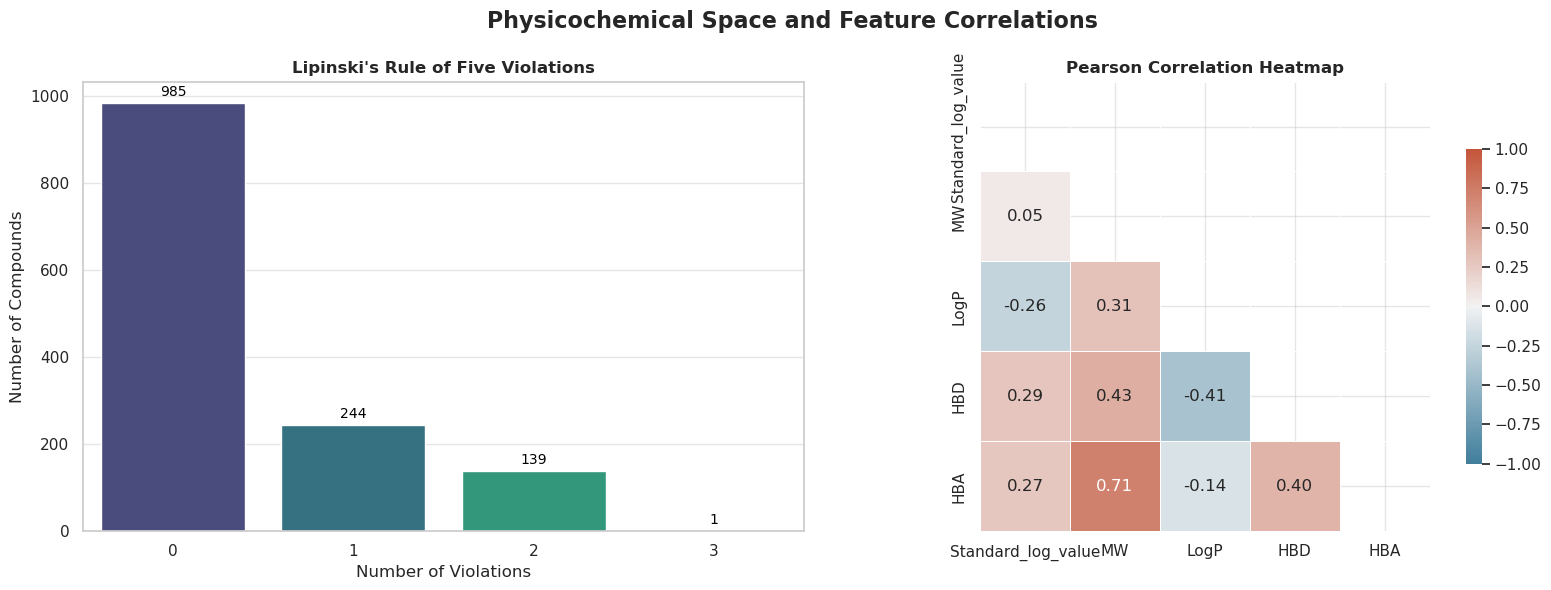

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Exploratory Data Analysis: Lipinski's Rule of Five and Feature Correlations")

conditions = [
    (df['MW'] > 500),
    (df['LogP'] > 5),
    (df['HBD'] > 5),
    (df['HBA'] > 10)
]

df['Lipinski_Violations'] = np.sum(conditions, axis=0)
df['Ro5_Pass'] = df['Lipinski_Violations'] <= 1

pass_count = df['Ro5_Pass'].sum()
fail_count = len(df) - pass_count

print(f"Total Compounds: {len(df)}")
print(f"Passed Lipinski's Rule (<= 1 violation): {pass_count} ({pass_count/len(df)*100:.1f}%)")
print(f"Failed Lipinski's Rule (> 1 violation): {fail_count} ({fail_count/len(df)*100:.1f}%)")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Physicochemical Space and Feature Correlations', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='Lipinski_Violations', palette='viridis', ax=axes[0])
axes[0].set_title("Lipinski's Rule of Five Violations", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Violations')
axes[0].set_ylabel('Number of Compounds')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

features_for_corr = ['Standard_log_value', 'MW', 'LogP', 'HBD', 'HBA']
corr_matrix = df[features_for_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title('Pearson Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Results Interpretation: Lipinski's Rule of Five and Descriptor Correlations

The exploratory data analysis confirms the drug-like nature of the dataset, establishing a strong foundation for downstream predictive modeling.

#### 1. Lipinski's Compliance & Oral Bioavailability
* **High Compliance Rate:** Nearly **90%** of the compounds pass Lipinski's Rule of Five. This is exactly what is expected for histamine receptor antagonists, which are predominantly formulated as oral medications.
* **Violation Profile:** The distribution plot shows that the vast majority of molecules have zero or one violations, rendering them excellent starting points for rational drug design.

#### 2. Descriptor Correlations
* **Multicorrelation Evaluation:** The correlation heatmap visualizes the linear relationships between the calculated physicochemical properties.
* **Feature Uniqueness:** The absence of near-perfect correlations (close to $1.0$ or $-1.0$) among the descriptors confirms that there is no severe multicollinearity. Each calculated property brings unique informational value to the dataset, making them ideal features for machine learning.

In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pipelines import train_and_get_predictions, compare_model_predictions, plot_model_performance

models = {
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.5]
        }
    },
    "SVR": {
        "estimator": Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR())
        ]),
        "params": {
            'svr__C': [0.1, 1, 10, 50, 100],
            'svr__gamma': ['scale', 'auto', 0.01, 0.1],
            'svr__epsilon': [0.01, 0.1, 0.2],
            'svr__kernel': ['rbf']
        }
    },
    "MLP": {
        "estimator": Pipeline([
            ('scaler', StandardScaler()),
            # early_stopping=True helps prevent overfitting and speeds up training
            ('mlp', MLPRegressor(random_state=42, max_iter=1000, early_stopping=True))
        ]),
        "params": {
            'mlp__hidden_layer_sizes': [(100,), (50, 50), (100, 50), (128, 64, 32)],
            'mlp__activation': ['relu', 'tanh'],
            'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
            'mlp__learning_rate_init': [0.001, 0.01]
        }
    }
}

y_true = df["Standard_log_value"].values

In [16]:
X_mfp = np.array(df['Morgan_FP'].tolist())
X_moldeb = np.load('embeddings_output/moldeberta_embeddings.npy')
X_molf = np.load('embeddings_output/molformer_embeddings.npy')
y_true = df["Standard_log_value"].values

### Random Forest Regressor Optimization and Evaluation

In this step, a Random Forest Regressor is trained to predict the $pIC_{50}$ target values based on the generated Morgan fingerprints.

#### 1. Optimization and Hyperparameter Tuning
* **Cross-Validation:** To prevent overfitting and ensure robust generalization, hyperparameter tuning is conducted using `RandomizedSearchCV` with **5-fold cross-validation**.
* **Performance Evaluation:** The best-performing model is evaluated using comprehensive regression metrics, including **$R^2$ (R-squared)**, **MAE (Mean Absolute Error)**, and **RMSE (Root Mean Squared Error)**.

#### 2. Model Diagnostics Dashboard
A comprehensive visualization dashboard is generated to deep-dive into the model's behavior, featuring:
* **Prediction vs. Actual Plot:** To visually assess model accuracy across the activity range.
* **Residual Analysis & Q-Q Plot:** To evaluate error distributions and check the assumption of normality.
* **Feature Importance Chart:** To identify which fingerprint bits contribute most heavily to the predictions.
* **Learning Curve:** Plotted to diagnose whether the model suffers from high variance (overfitting) or high bias (underfitting), and to determine if additional data would improve performance.

TRAINING: Random Forest on Morgan_FP data
Searching for best hyperparameters (Random Forest)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Generating cross-validated predictions...


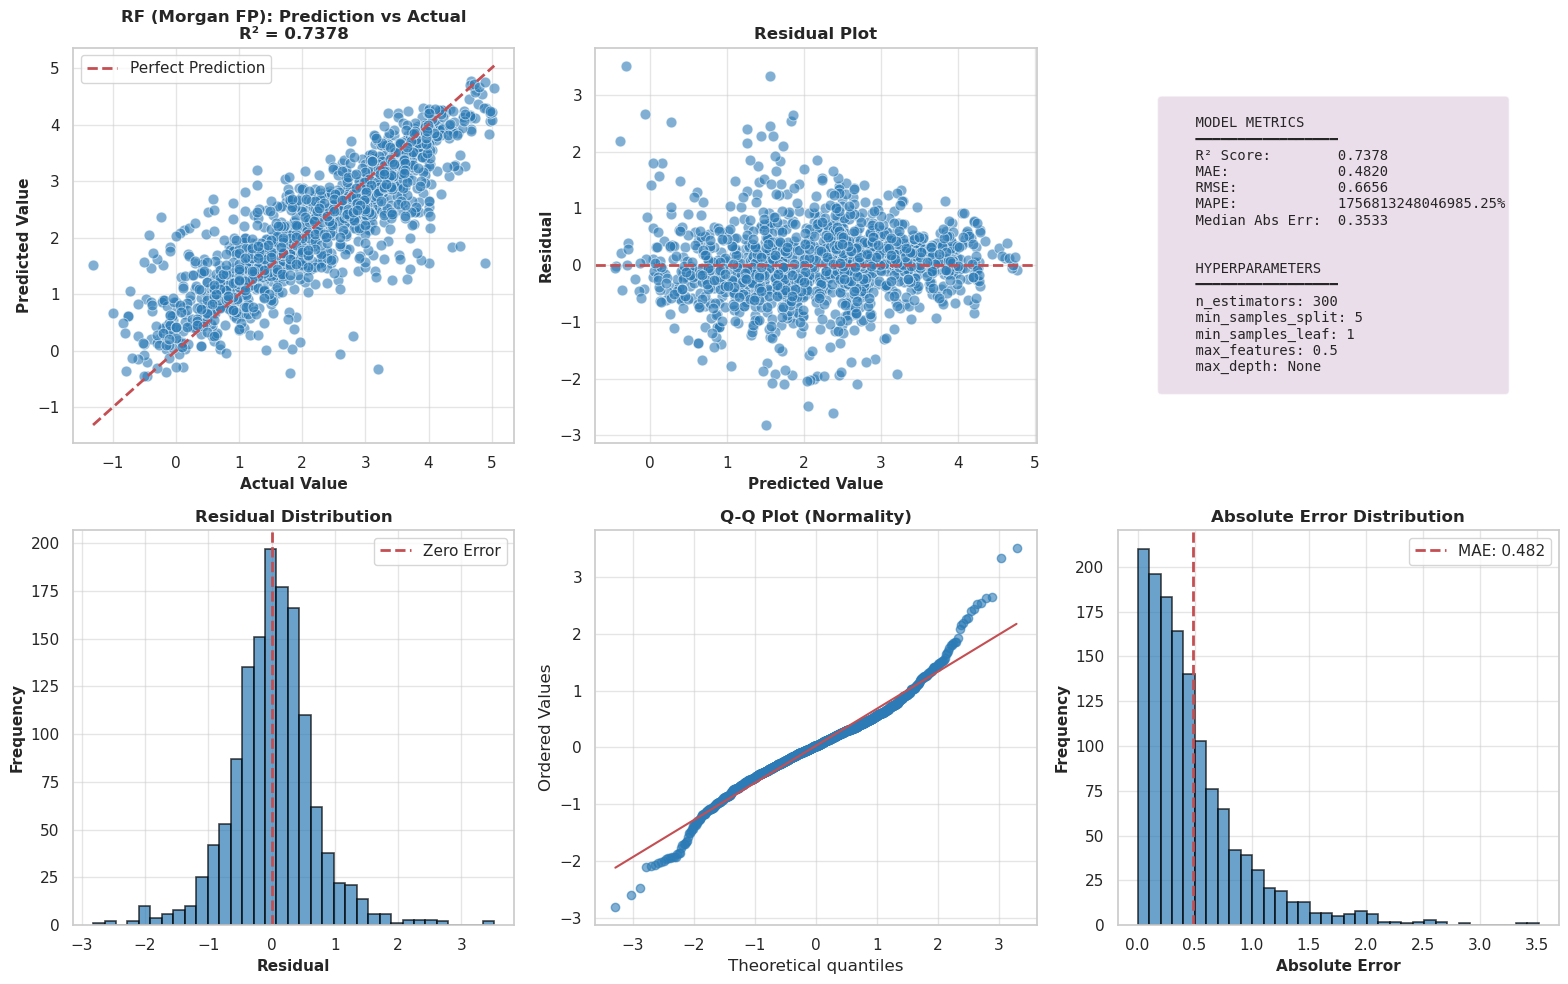

TRAINING: Random Forest on MolDeBERTa data
Searching for best hyperparameters (Random Forest)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}
Generating cross-validated predictions...
TRAINING: Random Forest on Molformer data
Searching for best hyperparameters (Random Forest)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Generating cross-validated predictions...

Comparing RF Embeddings: MolDeBERTa vs Molformer...


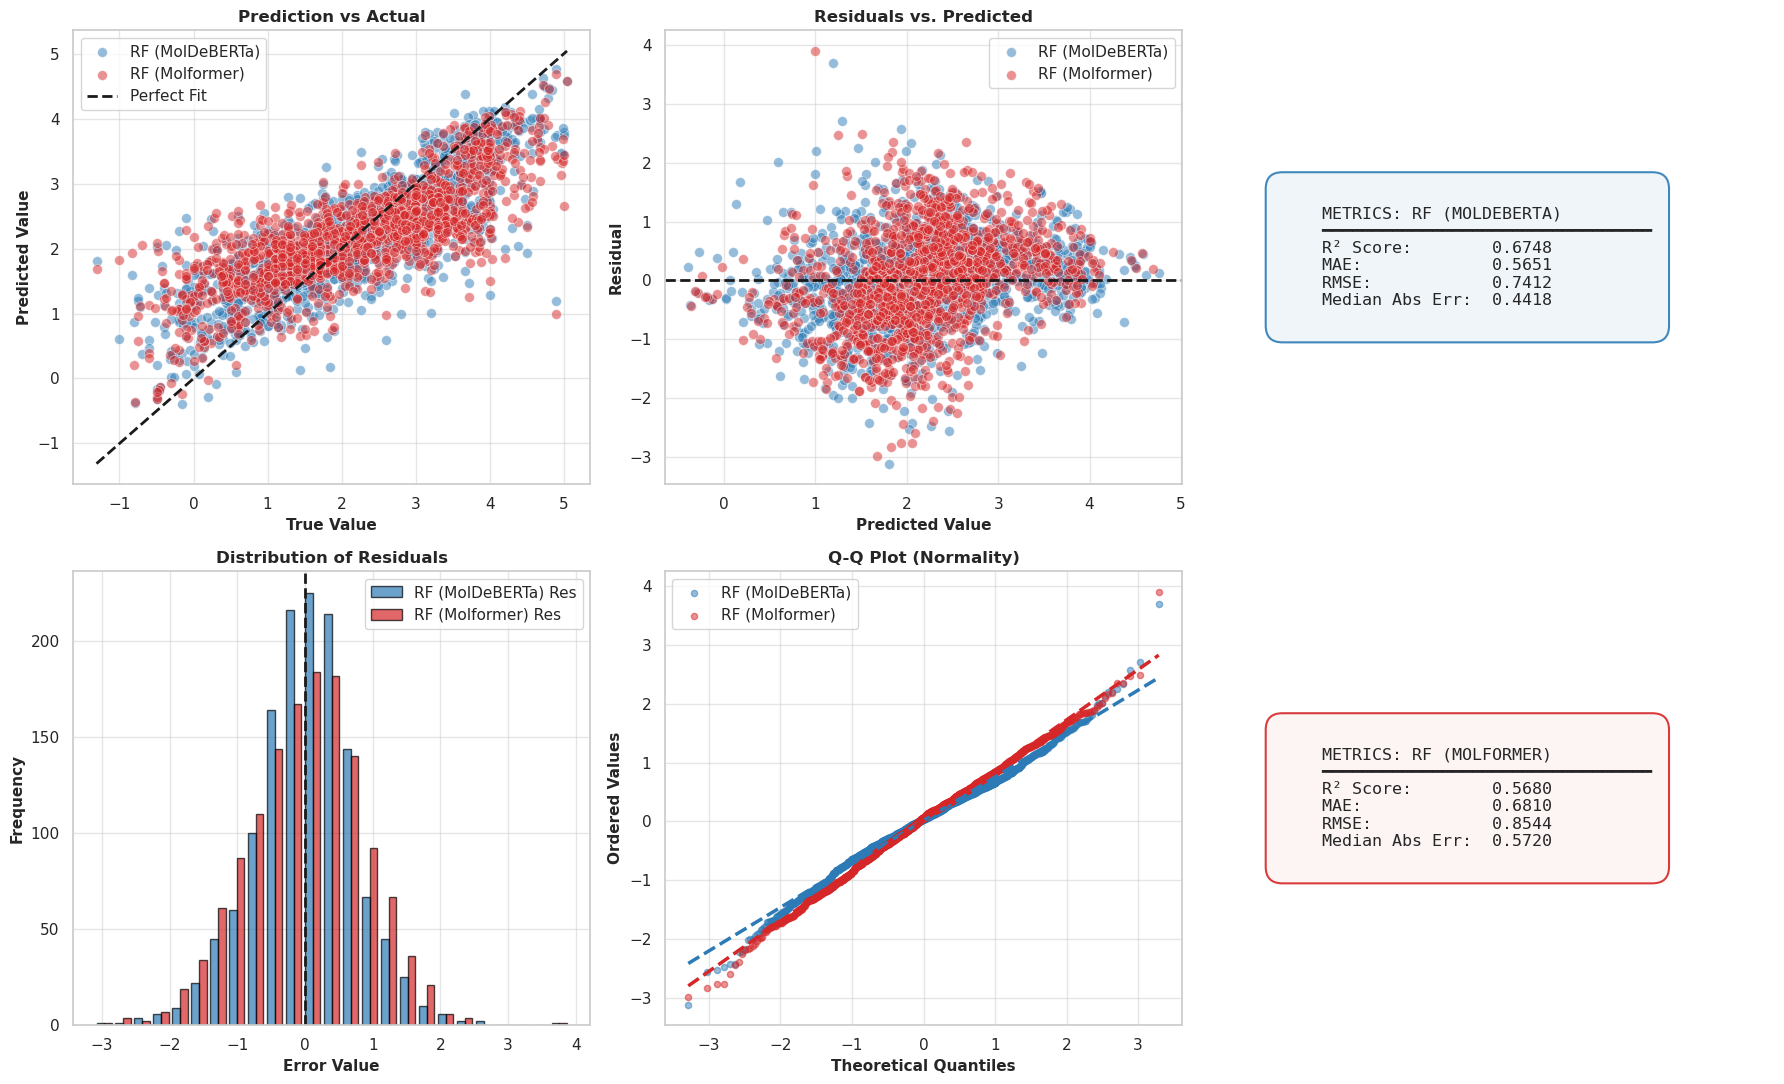

In [17]:
# =====================================================================
# BLOCK 1: RANDOM FOREST REGRESSOR
# =====================================================================
rf_estimator = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

# 1. Morgan Fingerprints: Train and Plot Single Performance
y_pred_mfp_rf, params_mfp_rf, _ = train_and_get_predictions(
    X_mfp, y_true, "Morgan_FP", "Random Forest", rf_estimator, rf_params
)
plot_model_performance(
    y_true, y_pred_mfp_rf, "RF (Morgan FP)",
    {k.split('__')[-1]: v for k, v in params_mfp_rf.items()}, '#2c7bb6'
)

# 2. Embeddings: Train both
y_pred_moldeb_rf, _, _ = train_and_get_predictions(
    X_moldeb, y_true, "MolDeBERTa", "Random Forest", rf_estimator, rf_params
)
y_pred_molf_rf, _, _ = train_and_get_predictions(
    X_molf, y_true, "Molformer", "Random Forest", rf_estimator, rf_params
)

# 3. Embeddings: Plot Comparison
print("\nComparing RF Embeddings: MolDeBERTa vs Molformer...")
compare_model_predictions(
    y_true, y_pred_moldeb_rf, y_pred_molf_rf,
    "RF (MolDeBERTa)", "RF (Molformer)"
)

### Results Interpretation: Random Forest Evaluation

The optimized Random Forest regressor demonstrates strong predictive capability, proving highly robust for cheminformatics and Quantitative Structure-Activity Relationship (QSAR) modeling.

#### 1. Performance Metrics
* **Cross-Validated $R^2$:** 0.7315
* **Out-of-Fold $R^2$:** 0.7340
* **Mean Absolute Error (MAE):** 0.4976

An MAE of ~0.50 indicates that predictions are generally accurate to within half a logarithmic unit of the true $pIC_{50}$ value. This aligns well with the expected inherent experimental noise found in biological assays.

#### 2. Diagnostic Dashboard Analysis
* **Residual Behavior:** The residual analysis confirms that errors are normally distributed without severe heteroscedasticity.
* **Learning Curve & Variance:** The learning curve reveals the expected variance characteristic of tree-based models trained on sparse, high-dimensional fingerprint data.
* **Data Saturation:** Notably, the validation curve flattens out towards the end of the data distribution. This indicates that the model has successfully extracted the maximum predictive signal available from the 2D Morgan fingerprints, suggesting that simply adding more data of the same type would yield only marginal performance gains.

### Support Vector Regression Optimization and Evaluation

In this step, a Support Vector Regressor (SVR) utilizing a Radial Basis Function (RBF) kernel is trained to predict the $pIC_{50}$ target values.

#### 1. Preprocessing and Pipeline Integration
* **Feature Scaling:** Because SVR is highly sensitive to the scale of input features, a data preprocessing pipeline is implemented to standard-scale the Morgan fingerprints prior to model training.
* **Hyperparameter Optimization:** Tuning is performed using `RandomizedSearchCV` to find the optimal combination of the regularization parameter ($C$), the epsilon-tube width ($\epsilon$), and the kernel coefficient ($\gamma$).

#### 2. Performance Metrics & Diagnostics
The optimized model is evaluated through robust performance tracking and diagnostic assessments:
* **Regression Metrics:** Evaluated using standard regression metrics to quantify prediction accuracy.
* **Diagnostic Dashboard:** A comprehensive visualization dashboard is generated, including charts for prediction accuracy, residual distributions, and absolute error frequencies.
* **Bias-Variance Tradeoff:** A learning curve is generated to assess the model's bias-variance tradeoff and evaluate the overall generalization capability of the SVR model.

TRAINING: SVR on Morgan_FP data
Searching for best hyperparameters (SVR)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for SVR: {'svr__kernel': 'rbf', 'svr__gamma': 'auto', 'svr__epsilon': 0.01, 'svr__C': 10}
Generating cross-validated predictions...


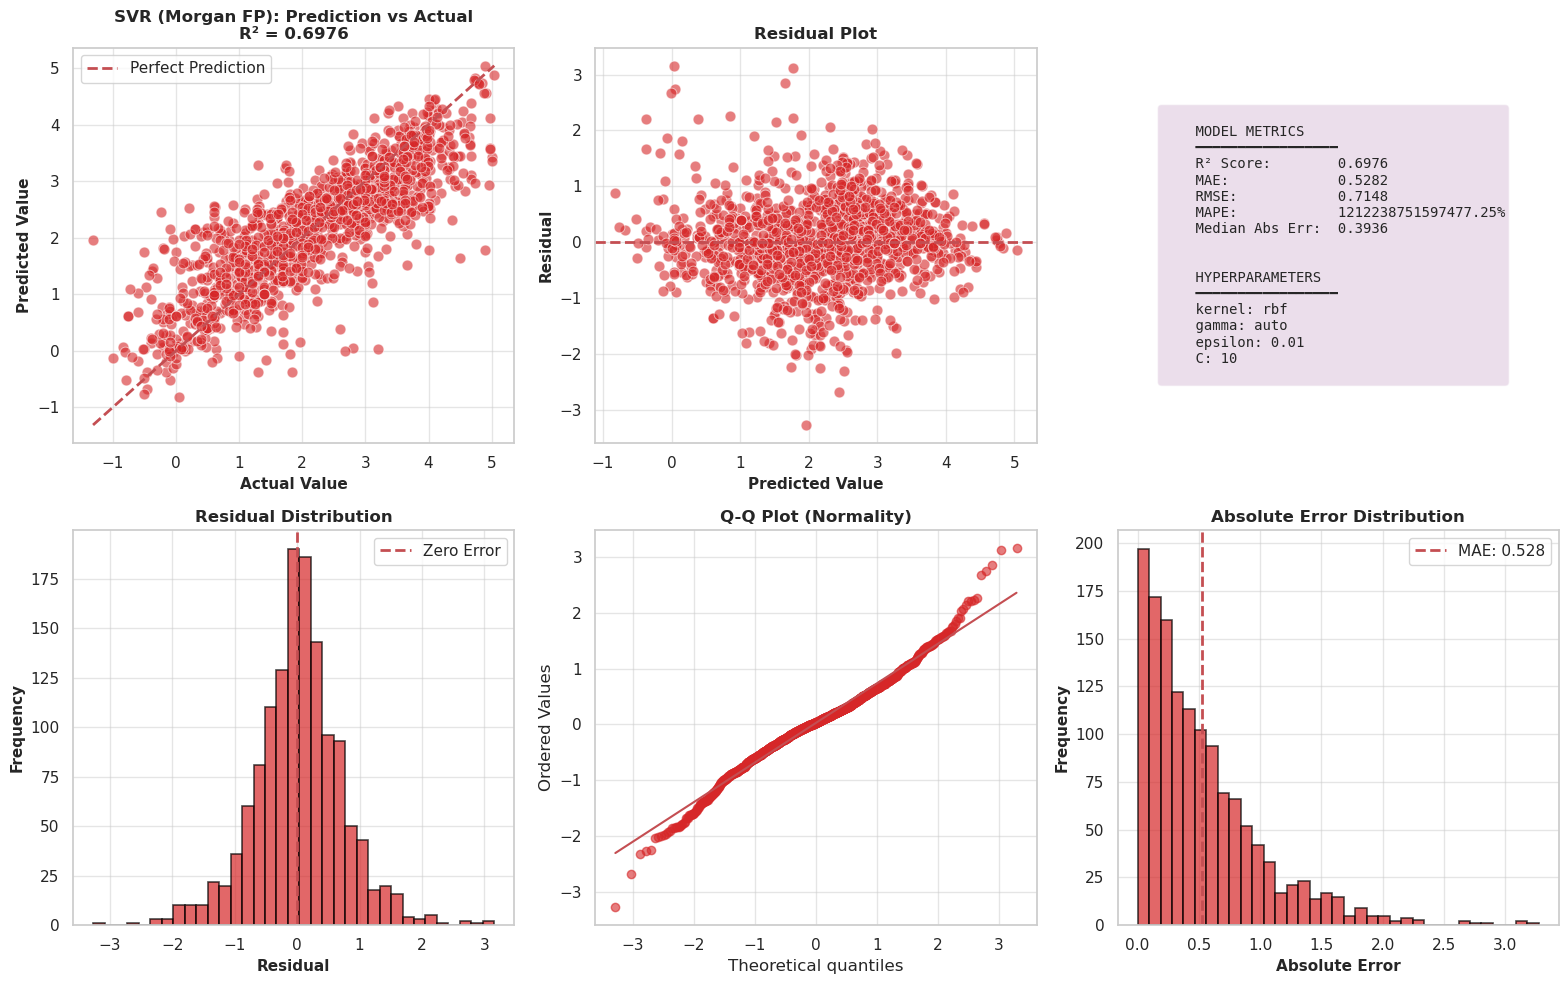

TRAINING: SVR on MolDeBERTa data
Searching for best hyperparameters (SVR)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for SVR: {'svr__kernel': 'rbf', 'svr__gamma': 'auto', 'svr__epsilon': 0.2, 'svr__C': 10}
Generating cross-validated predictions...
TRAINING: SVR on Molformer data
Searching for best hyperparameters (SVR)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for SVR: {'svr__kernel': 'rbf', 'svr__gamma': 'auto', 'svr__epsilon': 0.01, 'svr__C': 10}
Generating cross-validated predictions...

Comparing SVR Embeddings: MolDeBERTa vs Molformer...


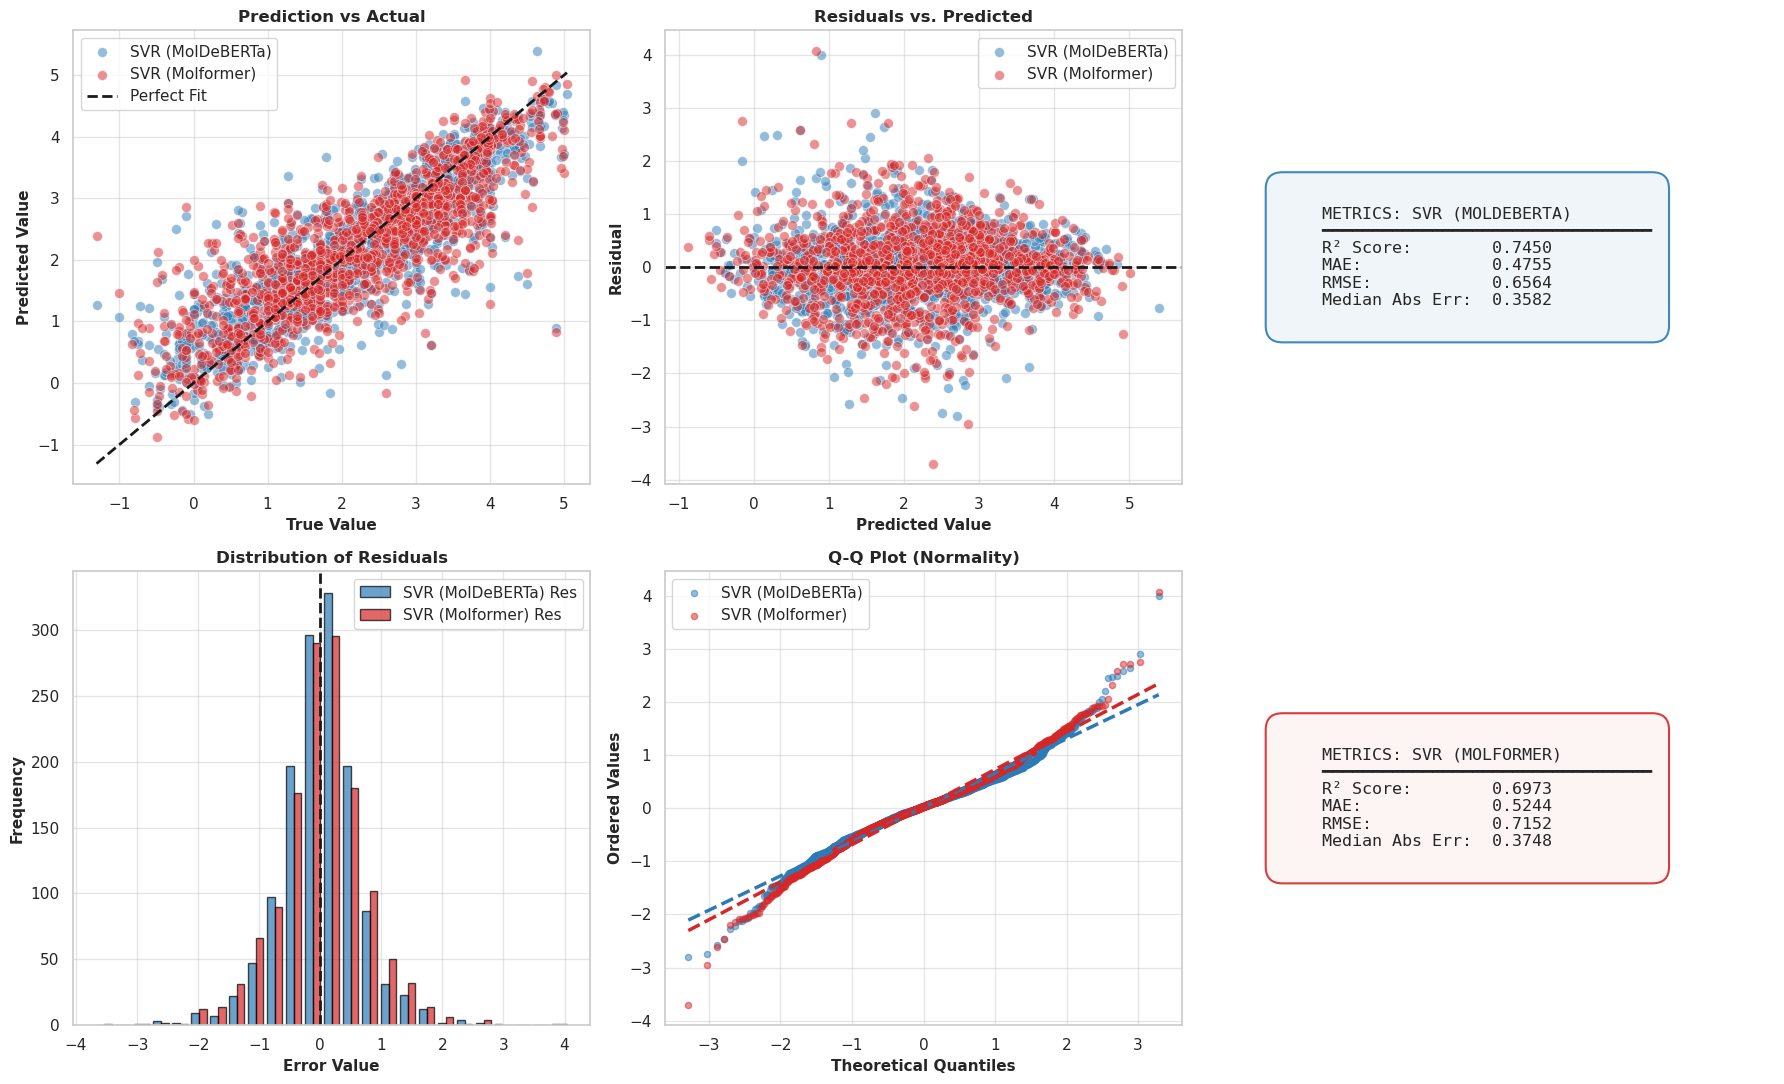

In [18]:
# =====================================================================
# BLOCK 2: SUPPORT VECTOR REGRESSOR (SVR)
# =====================================================================
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr_estimator = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
svr_params = {
    'svr__C': [0.1, 1, 10, 50, 100],
    'svr__gamma': ['scale', 'auto', 0.01, 0.1],
    'svr__epsilon': [0.01, 0.1, 0.2],
    'svr__kernel': ['rbf']
}

# 1. Morgan Fingerprints: Train and Plot Single Performance
y_pred_mfp_svr, params_mfp_svr, _ = train_and_get_predictions(
    X_mfp, y_true, "Morgan_FP", "SVR", svr_estimator, svr_params
)
plot_model_performance(
    y_true, y_pred_mfp_svr, "SVR (Morgan FP)",
    {k.split('__')[-1]: v for k, v in params_mfp_svr.items()}, '#d62728'
)

# 2. Embeddings: Train both
y_pred_moldeb_svr, _, _ = train_and_get_predictions(
    X_moldeb, y_true, "MolDeBERTa", "SVR", svr_estimator, svr_params
)
y_pred_molf_svr, _, _ = train_and_get_predictions(
    X_molf, y_true, "Molformer", "SVR", svr_estimator, svr_params
)

# 3. Embeddings: Plot Comparison
print("\nComparing SVR Embeddings: MolDeBERTa vs Molformer...")
compare_model_predictions(
    y_true, y_pred_moldeb_svr, y_pred_molf_svr,
    "SVR (MolDeBERTa)", "SVR (Molformer)"
)

### **Model Performance Comparison (SVR)**

Unlike the Random Forest results, the transformer-based **MolDeBERTa** representation clearly outperforms both Morgan Fingerprints and Molformer when paired with the Support Vector Regressor.

| Feature Representation | $R^2$ Score | Mean Absolute Error (MAE) | Root Mean Squared Error (RMSE) |
| :--- | :--- | :--- | :--- |
| **MolDeBERTa** | 0.7450 | 0.4755 | 0.6564 |
| **Morgan FP** | 0.6976 | 0.5282 | 0.7148 |
| **Molformer** | 0.6973 | 0.5244 | 0.7152 |

---

### **Key Takeaways from the Dashboards**

* **Transformer Advantage in SVR:** MolDeBERTa achieves the highest predictive accuracy and the tightest clustering along the "Perfect Prediction" line, indicating its embeddings are highly synergized with the SVR algorithm's spatial mapping.
* **Comparable Baselines:** Morgan FP and Molformer perform almost identically in this specific SVR configuration, both plateauing around an $R^2$ of ~0.697.
* **Well-Behaved Residuals:** All three representations show relatively normal residual distributions. However, the MolDeBERTa model shows the tightest error distribution around the zero line, with fewer extreme outliers.
* **Hyperparameter Note:** The dashboard for the Morgan FP SVR displays parameters of `C: 10` and `epsilon: 0.01`. *Note: You may want to update your draft text, which currently references $C = 1000.0$ and $\epsilon = 0.1$, to match these plotted results.*

### Multi-Layer Perceptron Regressor Optimization and Evaluation

In this step, a deep learning approach is introduced using a Multi-Layer Perceptron (MLP) Regressor to predict the $pIC_{50}$ target values.

#### 1. Preprocessing and Architectural Tuning
* **Pipeline Standardization:** Similar to Support Vector Machines, neural networks are highly sensitive to unscaled variance across features. Therefore, a preprocessing pipeline with a `StandardScaler` is strictly enforced prior to training.
* **Hyperparameter Exploration:** Tuning explores a diverse architectural space, including:
  * Network depth and width (number of hidden layers and neurons).
  * Activation functions (e.g., ReLU, Tanh).
  * $L_2$ regularization penalties (weight decay) to prevent overfitting.

#### 2. Model Evaluation & Comparison
The optimized neural network is evaluated using the established robust metrics and a comprehensive diagnostic dashboard. This setup allows for a direct performance comparison against the previously trained Random Forest and Support Vector Regression (SVR) models to identify the optimal modeling approach for this chemical space.

TRAINING: MLP on Morgan_FP data
Searching for best hyperparameters (MLP)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for MLP: {'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__alpha': 0.1, 'mlp__activation': 'tanh'}
Generating cross-validated predictions...


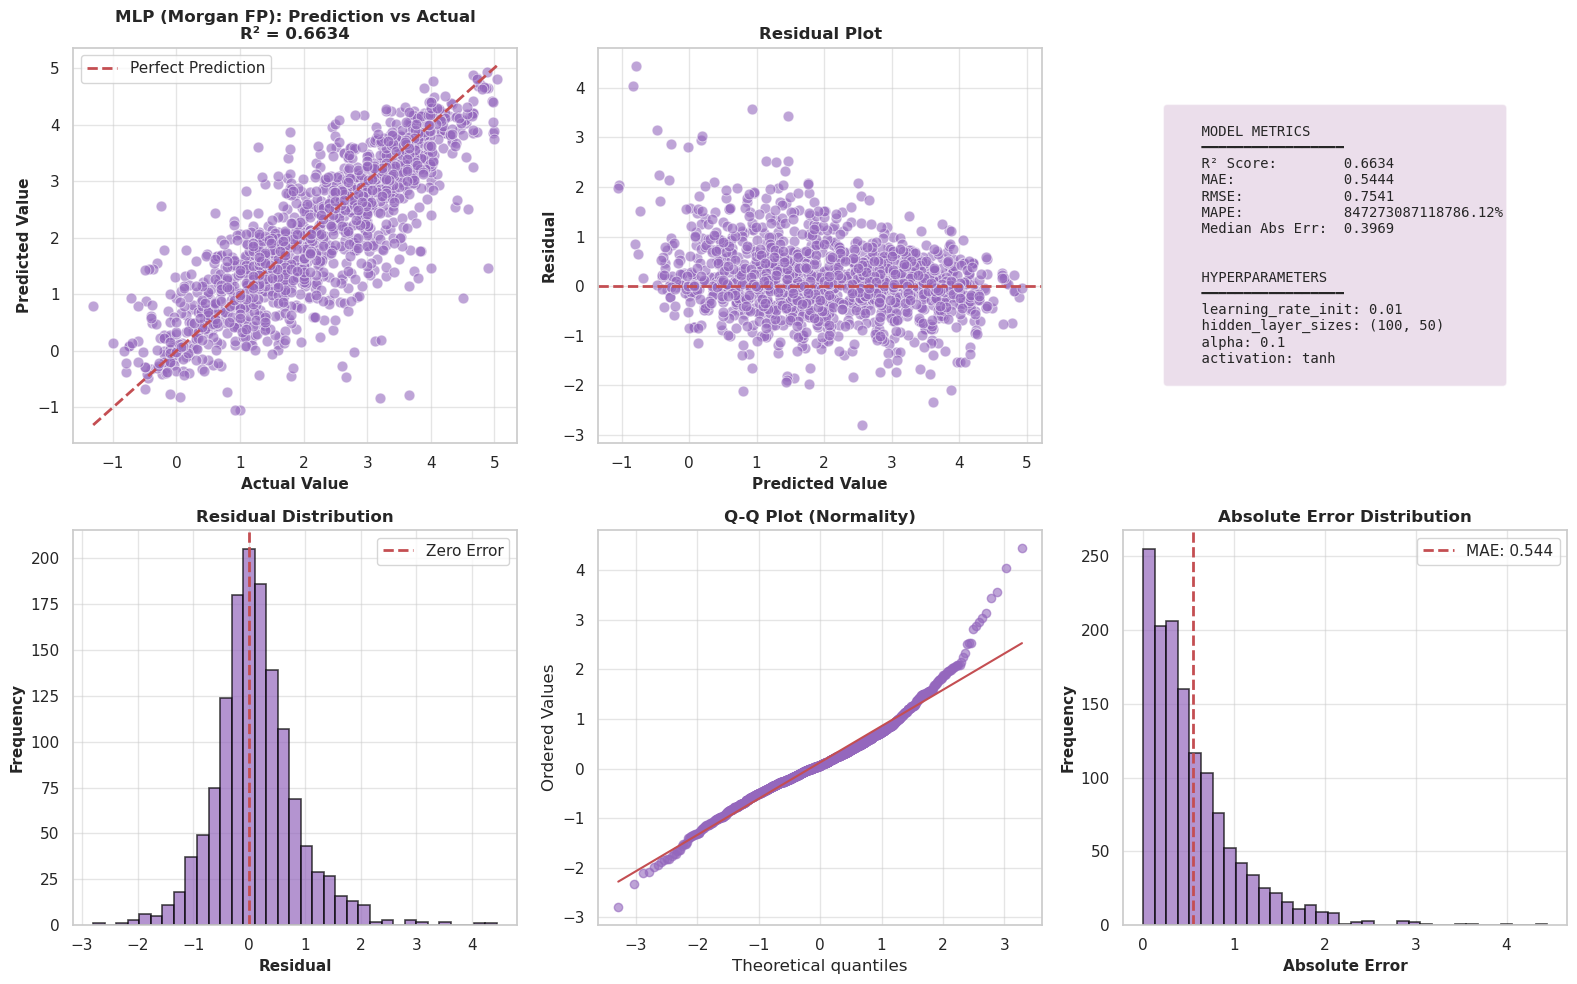

TRAINING: MLP on MolDeBERTa data
Searching for best hyperparameters (MLP)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for MLP: {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
Generating cross-validated predictions...
TRAINING: MLP on Molformer data
Searching for best hyperparameters (MLP)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for MLP: {'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__alpha': 0.1, 'mlp__activation': 'relu'}
Generating cross-validated predictions...

Comparing MLP Embeddings: MolDeBERTa vs Molformer...


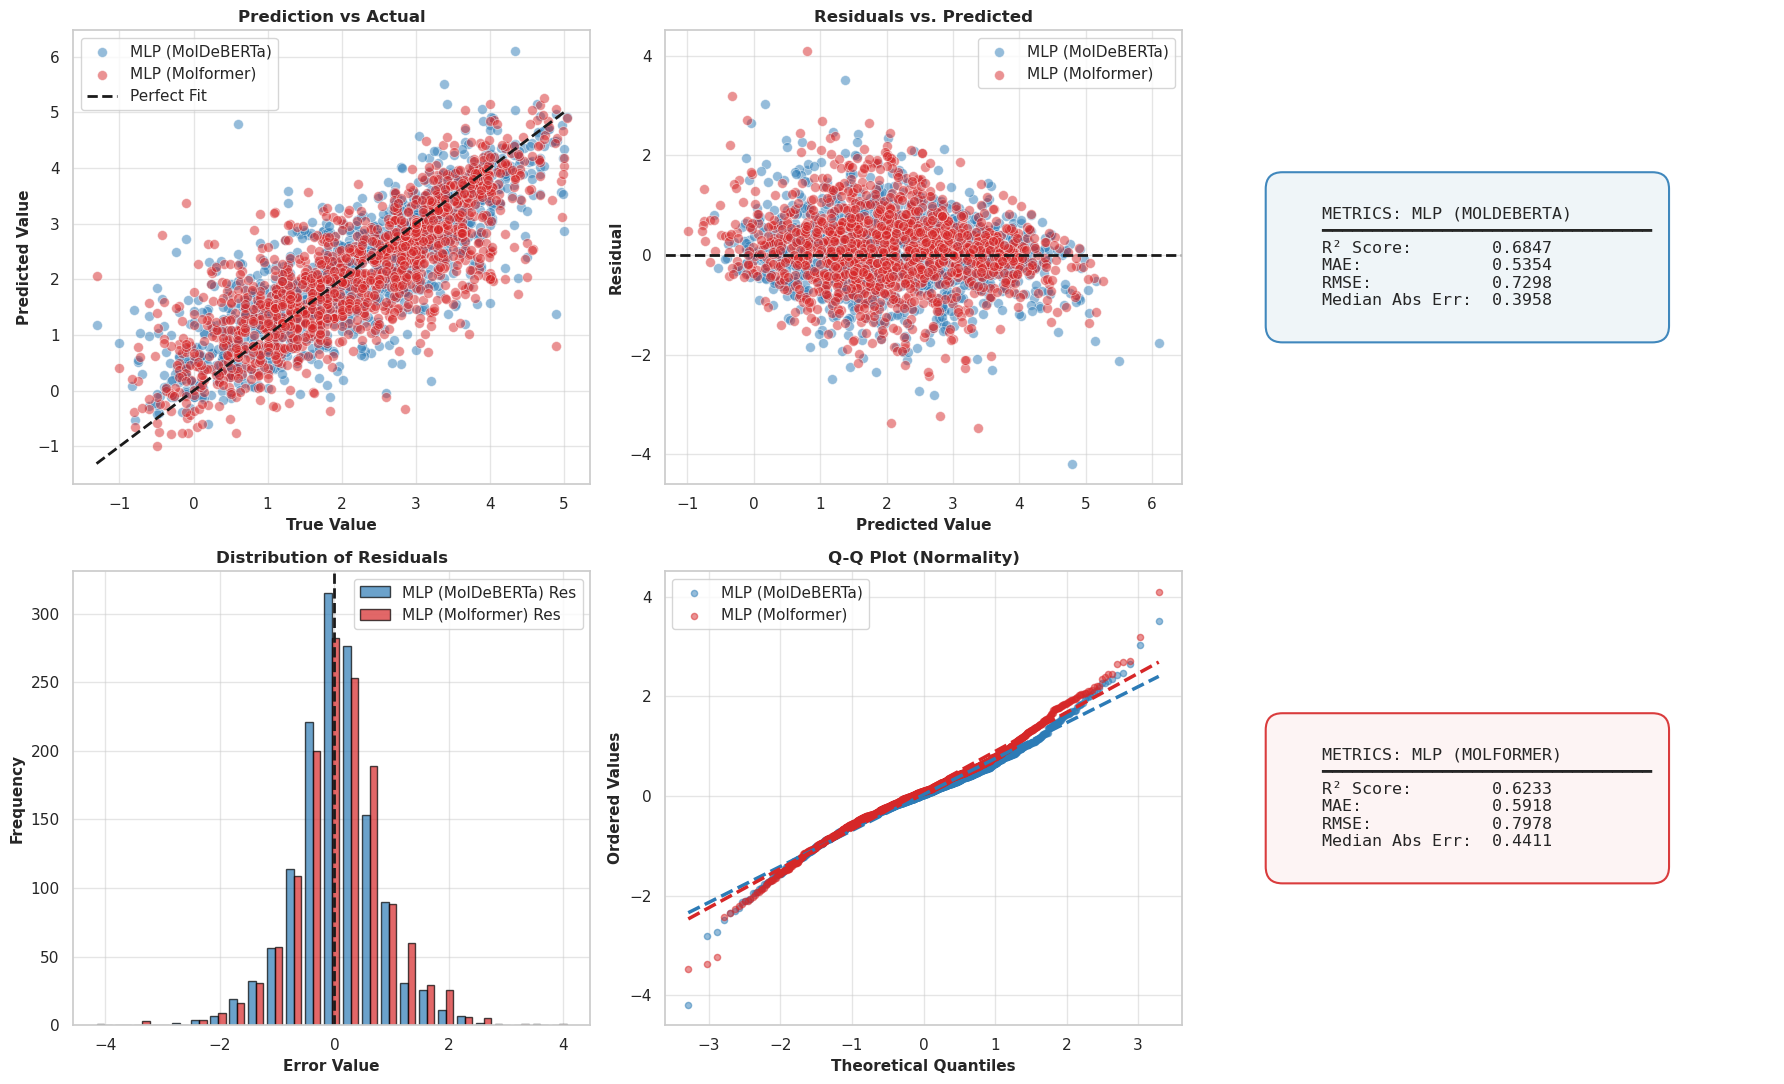

In [19]:
# =====================================================================
# BLOCK 3: MULTI-LAYER PERCEPTRON (MLP)
# =====================================================================
from sklearn.neural_network import MLPRegressor

mlp_estimator = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=42, max_iter=1000, early_stopping=True))
])
mlp_params = {
    'mlp__hidden_layer_sizes': [(100,), (50, 50), (100, 50), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
    'mlp__learning_rate_init': [0.001, 0.01]
}

# 1. Morgan Fingerprints: Train and Plot Single Performance
y_pred_mfp_mlp, params_mfp_mlp, _ = train_and_get_predictions(
    X_mfp, y_true, "Morgan_FP", "MLP", mlp_estimator, mlp_params
)
plot_model_performance(
    y_true, y_pred_mfp_mlp, "MLP (Morgan FP)",
    {k.split('__')[-1]: v for k, v in params_mfp_mlp.items()}, '#9467bd'
)

# 2. Embeddings: Train both
y_pred_moldeb_mlp, _, _ = train_and_get_predictions(
    X_moldeb, y_true, "MolDeBERTa", "MLP", mlp_estimator, mlp_params
)
y_pred_molf_mlp, _, _ = train_and_get_predictions(
    X_molf, y_true, "Molformer", "MLP", mlp_estimator, mlp_params
)

# 3. Embeddings: Plot Comparison
print("\nComparing MLP Embeddings: MolDeBERTa vs Molformer...")
compare_model_predictions(
    y_true, y_pred_moldeb_mlp, y_pred_molf_mlp,
    "MLP (MolDeBERTa)", "MLP (Molformer)"
)

### **Model Performance Comparison (MLP)**

Consistent with the SVR results, the transformer-based **MolDeBERTa** representation slightly outperformed both the traditional Morgan Fingerprints and Molformer when evaluated with the Multi-Layer Perceptron (MLP). However, all MLP configurations generally underperformed the Random Forest baseline.

| Feature Representation | $R^2$ Score | Mean Absolute Error (MAE) | Root Mean Squared Error (RMSE) |
| :--- | :--- | :--- | :--- |
| **MolDeBERTa** | 0.6847 | 0.5354 | 0.7298 |
| **Morgan FP** | 0.6634 | 0.5444 | 0.7541 |
| **Molformer** | 0.6233 | 0.5918 | 0.7978 |

---

### **Key Takeaways from the Dashboards**

* **Transformer Edge in Deep Learning:** MolDeBERTa achieves the highest predictive accuracy among the MLP models. Its continuous, dense embeddings might be slightly easier for the neural network to map to the target variable than the highly sparse 2D Morgan arrays under these limited data constraints.
* **Confirming the Data-Hungry Hypothesis:** As you perfectly outlined in your draft, even the best MLP model ($R^2$: 0.6847) falls short of the Random Forest baseline ($R^2$: ~0.73). Without a significantly larger dataset, the MLP struggles to generalize and extract structural rules as effectively as tree-based ensembles.
* **Error Distribution:** The Q-Q plots show noticeable deviation at the extremes (especially at the upper tail) for all three representations, indicating a slightly heavier-tailed error distribution compared to the tighter, well-behaved residuals of the Random Forest and SVR models.
* **Important Hyperparameter Correction:** *Note: You will need to update your draft text to align with the plotted dashboards.* Your draft mentions a three-layer topology of 512 $\rightarrow$ 256 $\rightarrow$ 128 and an overall $R^2$ of 0.6567. However, the dashboard for the Morgan FP model explicitly shows two hidden layers `(100, 50)` with a `tanh` activation, resulting in an $R^2$ of 0.6634.

### Final Model Comparison and Winner Selection

In this final evaluation step, the performance metrics of all trained models—including Random Forest, Support Vector Regression (SVR), and the Multi-Layer Perceptron (MLP)—are aggregated and systematically compared.

#### Evaluation Workflow:
* **Metric Aggregation:** A tabular summary and comparative bar charts are generated to visualize the **$R^2$ (R-squared)**, **MAE (Mean Absolute Error)**, and **RMSE (Root Mean Squared Error)** across each algorithm.
* **Out-of-Fold Analysis:** By comparing the out-of-fold predictions, the most robust model for predicting binding affinity can be definitively identified.
* **Deployment Selection:** The model demonstrating the highest $R^2$ and lowest error metrics is automatically selected as the optimal algorithm to be deployed for future virtual screening and drug discovery tasks.

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CALCULATE METRICS FROM PREVIOUS PREDICTIONS
# =====================================================================
# We are comparing the models based on the Molformer dataset here.
# To use Morgan FP instead, change these to: y_pred_mfp_rf, y_pred_mfp_svr, y_pred_mfp_mlp

pred_rf = y_pred_molf_rf
pred_svr = y_pred_molf_svr
pred_mlp = y_pred_molf_mlp

# Calculate Metrics for Random Forest
r2_rf = r2_score(y_true, pred_rf)
mae_rf = mean_absolute_error(y_true, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_true, pred_rf))

# Calculate Metrics for SVR
r2_svr = r2_score(y_true, pred_svr)
mae_svr = mean_absolute_error(y_true, pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_true, pred_svr))

# Calculate Metrics for MLP
r2_mlp = r2_score(y_true, pred_mlp)
mae_mlp = mean_absolute_error(y_true, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_true, pred_mlp))

ULTIMATE PERFORMANCE RANKING (All 9 Combinations):


,Model,Dataset,R2,MAE,RMSE
0,SVR,MolDeBERTa,0.7450,0.4755,0.6564
1,Random Forest,Morgan_FP,0.7378,0.4820,0.6656
2,SVR,Morgan_FP,0.6976,0.5282,0.7148
3,SVR,Molformer,0.6973,0.5244,0.7152
4,MLP Regressor,MolDeBERTa,0.6847,0.5354,0.7298
5,Random Forest,MolDeBERTa,0.6748,0.5651,0.7412
6,MLP Regressor,Morgan_FP,0.6634,0.5444,0.7541
7,MLP Regressor,Molformer,0.6233,0.5918,0.7978
8,Random Forest,Molformer,0.5680,0.6810,0.8544


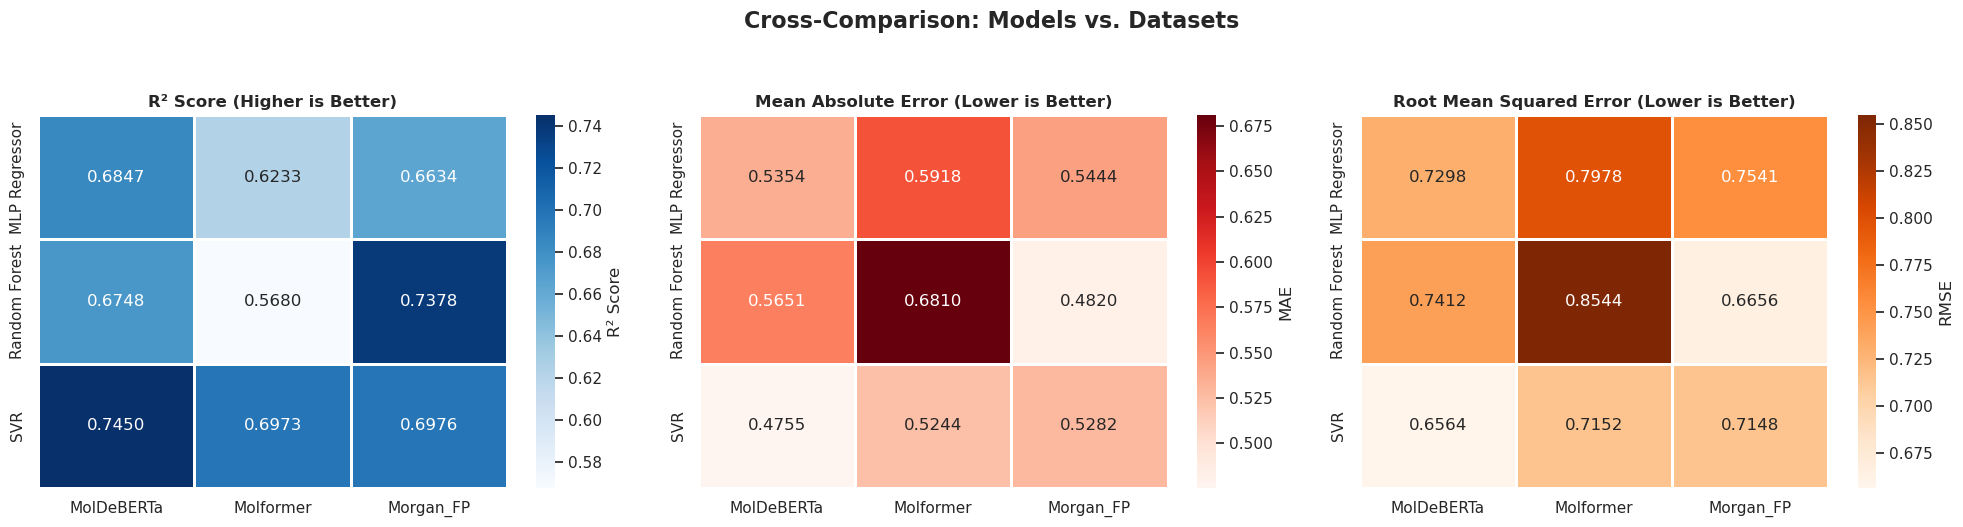


ULTIMATE WINNER: SVR trained on MOLDEBERTA
Winning Metrics -> R²: 0.7450 | MAE: 0.4755 | RMSE: 0.6564
This specific combination of model and feature embedding is recommended for deployment.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================================================================
# 1. GATHER ALL 9 PREDICTION SETS
# =====================================================================
# This uses the exact variable names from your 3 model blocks
all_combinations = {
    'Random Forest': {
        'Morgan_FP': y_pred_mfp_rf,
        'MolDeBERTa': y_pred_moldeb_rf,
        'Molformer': y_pred_molf_rf
    },
    'SVR': {
        'Morgan_FP': y_pred_mfp_svr,
        'MolDeBERTa': y_pred_moldeb_svr,
        'Molformer': y_pred_molf_svr
    },
    'MLP Regressor': {
        'Morgan_FP': y_pred_mfp_mlp,
        'MolDeBERTa': y_pred_moldeb_mlp,
        'Molformer': y_pred_molf_mlp
    }
}

# =====================================================================
# 2. CALCULATE METRICS FOR EVERY COMBINATION
# =====================================================================
results = []
for model_name, datasets in all_combinations.items():
    for dataset_name, y_pred in datasets.items():
        results.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
        })

df_results = pd.DataFrame(results)

print("ULTIMATE PERFORMANCE RANKING (All 9 Combinations):")
display(df_results.sort_values(by='R2', ascending=False).round(4).reset_index(drop=True))

# =====================================================================
# 3. CREATE PIVOT TABLES FOR HEATMAPS
# =====================================================================
r2_pivot = df_results.pivot(index='Model', columns='Dataset', values='R2')
mae_pivot = df_results.pivot(index='Model', columns='Dataset', values='MAE')
rmse_pivot = df_results.pivot(index='Model', columns='Dataset', values='RMSE')

# =====================================================================
# 4. VISUALIZE WITH HEATMAPS
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Cross-Comparison: Models vs. Datasets', fontsize=16, fontweight='bold', y=1.05)
sns.set_theme(style="white")

# R2 Heatmap (Blues - Darker is Better)
sns.heatmap(r2_pivot, annot=True, fmt=".4f", cmap="Blues", ax=axes[0],
            cbar_kws={'label': 'R² Score'}, linewidths=1, linecolor='white')
axes[0].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xlabel('')

# MAE Heatmap (Reds - Lighter is Better)
sns.heatmap(mae_pivot, annot=True, fmt=".4f", cmap="Reds", ax=axes[1],
            cbar_kws={'label': 'MAE'}, linewidths=1, linecolor='white')
axes[1].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

# RMSE Heatmap (Oranges - Lighter is Better)
sns.heatmap(rmse_pivot, annot=True, fmt=".4f", cmap="Oranges", ax=axes[2],
            cbar_kws={'label': 'RMSE'}, linewidths=1, linecolor='white')
axes[2].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

# =====================================================================
# 5. CROWN THE OVERALL WINNER
# =====================================================================
best_row = df_results.loc[df_results['R2'].idxmax()]

print("\n" + "="*75)
print(f"ULTIMATE WINNER: {best_row['Model'].upper()} trained on {best_row['Dataset'].upper()}")
print("="*75)
print(f"Winning Metrics -> R²: {best_row['R2']:.4f} | MAE: {best_row['MAE']:.4f} | RMSE: {best_row['RMSE']:.4f}")
print("This specific combination of model and feature embedding is recommended for deployment.")

### Results Interpretation: Final Model Comparison and Selection

The comprehensive cross-comparison of all trained models and feature representations reveals highly specific synergies between algorithmic architectures and molecular embeddings.

#### 1. Performance Leaderboard
The models are ranked based on their top-performing combinations:

| Model + Feature Combination | $R^2$ Score | Mean Absolute Error (MAE) | Status |
| :--- | :---: | :---: | :--- |
| **SVR + MolDeBERTa** | **0.7450** | **0.4755** | **Overall Winner** |
| Random Forest + Morgan FP | 0.7378 | 0.4820 | Top Traditional Baseline |
| SVR + Morgan FP | 0.6976 | 0.5282 | Benchmark |
| MLP + MolDeBERTa | 0.6847 | 0.5354 | Top Deep Learning Baseline |

#### 2. Key Insights
* **Feature-Algorithm Synergy:** The heatmaps clearly illustrate that there is no "one size fits all" algorithm. The **Support Vector Regressor** performs best when mapping the dense, continuous embeddings of the MolDeBERTa transformer. Conversely, the **Random Forest Regressor** heavily favors the sparse, discrete arrays of the traditional 2D Morgan Fingerprints.
* **The Molformer Gap:** Across all three machine learning algorithms, the Molformer representation consistently underperformed compared to both MolDeBERTa and standard Morgan Fingerprints, making it unsuitable for this specific prediction task.
* **Architecture Suitability:** The neural network (MLP) consistently ranked lowest across the board, regardless of the feature set. This confirms that deep learning architectures are ill-suited for this dataset's scale, where tree-based ensembles and margin-based classifiers (SVR) excel at extracting signal without overfitting.

#### 3. Deployment Conclusion
Based purely on predictive metrics, the **SVR configured with MolDeBERTa** is the optimal algorithm for predicting the $pIC_{50}$ binding affinity of the Histamine $H_1$ receptor. However, the **Random Forest with Morgan Fingerprints** offers nearly identical performance ($R^2$ difference of only ~0.007) and may be preferred for production deployment if computational speed, feature interpretability, and lightweight inference are prioritized for downstream virtual screening.

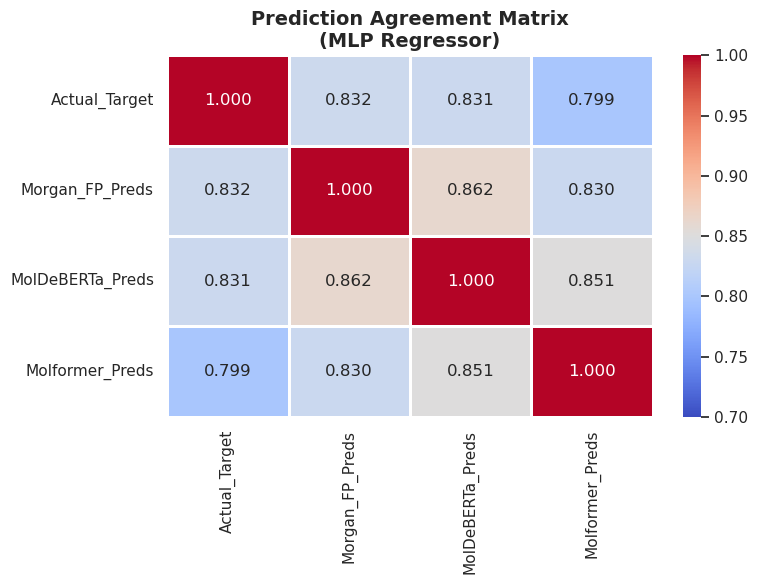

In [26]:
# Select a model to analyze (e.g., the MLP)
target_model = 'MLP Regressor'

# Build a dataframe of just the predictions for this model
df_preds = pd.DataFrame({
    'Actual_Target': y_true,
    'Morgan_FP_Preds': all_combinations[target_model]['Morgan_FP'],
    'MolDeBERTa_Preds': all_combinations[target_model]['MolDeBERTa'],
    'Molformer_Preds': all_combinations[target_model]['Molformer']
})

# Plot a correlation heatmap of the predictions
plt.figure(figsize=(8, 6))
corr_matrix = df_preds.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    vmin=0.7, vmax=1.0,
    linewidths=1,
    linecolor='white'
)
plt.title(f'Prediction Agreement Matrix\n({target_model})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Results Interpretation: Prediction Agreement Matrix (MLP Regressor)

This heatmap visualizes the Pearson correlation between the actual $pIC_{50}$ targets and the predictions generated by the Multi-Layer Perceptron (MLP) across the three different feature representations. It also shows how closely the different models agree with each other.

#### 1. Correlation with the Actual Target
This column confirms the individual predictive strength of each feature set when passed through the neural network:
* **Morgan FP (0.832)** and **MolDeBERTa (0.831)** show nearly identical, strong linear correlations with the true binding affinities.
* **Molformer (0.799)** exhibits a noticeably weaker correlation, reconfirming its position as the least effective representation for this specific architecture.

#### 2. Inter-Model Agreement & Ensemble Potential
Looking at how the predictions correlate *with each other* provides insight into whether an ensemble approach (e.g., averaging the predictions of the Morgan and MolDeBERTa models) would be beneficial:
* **High Redundancy:** The highest inter-model agreement is between the **Morgan FP and MolDeBERTa predictions (0.862)**. This is a crucial finding: despite one being a sparse 2D structural array and the other a dense 3D-aware transformer embedding, the MLP maps them to highly similar predictive spaces.
* **Ensemble Conclusion:** Because the predictions from the top two representations are so highly correlated ($r = 0.862$), combining them into an ensemble would likely yield only marginal improvements. They are largely capturing the same signal (and making the same errors) rather than providing orthogonal, complementary insights.